<a href="https://colab.research.google.com/github/Astronom2617/credit-card-fraud-detection/blob/main/Fraud_03_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fraud Detection — Models & Imbalance Handling

## Goal
Improve recall on the fraud class by addressing the class imbalance problem.
Build and compare multiple strategies: `class_weight`, SMOTE oversampling, and threshold tuning.

## Task
Binary classification on a highly imbalanced dataset (fraud ≈ 0.17% of all transactions).

## Target
`Class` — 0 = legitimate transaction, 1 = fraud.

## Input features
- `V1` … `V28` — anonymized PCA features
- `Time` — seconds elapsed since the first transaction in the dataset
- `Amount` — transaction amount
- `Hour` — engineered from `Time` (hour of the day, 0–23)

## Previous step
Baseline is done in `Fraud_02_Baseline` — DummyClassifier (accuracy paradox) and Logistic Regression (recall 0.57).
This notebook picks up where that left off, using the same time-based split and preprocessing pipeline.

## 1. Load Data

Same dataset and preprocessing pipeline as `Fraud_02_Baseline`.
Reproduced here to keep the notebook self-contained and reproducible.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

df = pd.read_csv('/content/drive/MyDrive/credit-card-fraud-detection/creditcard.csv')
df.shape

(284807, 31)

## 2. Train / Test Split

Time-based split — identical to `Fraud_02_Baseline`.
First 80% of transactions (sorted by `Time`) go to train, last 20% go to test.
This avoids data leakage: the model only learns from the past, never the future.

In [3]:
df_sorted = df.sort_values(by='Time')
split_idx = int(len(df) * 0.8)

train = df_sorted.iloc[:split_idx]
test = df_sorted.iloc[split_idx:]

## 3. Feature Matrix

Separate target column (`Class`) from input features.
`.copy()` is called to avoid `SettingWithCopyWarning` when adding new columns later.

In [4]:
X_train = train.drop('Class', axis=1)
y_train = train['Class']

X_test = test.drop('Class', axis=1)
y_test = test['Class']

In [5]:
X_train = X_train.copy()
X_test = X_test.copy()

## 4. Feature Engineering — Hour

`Time` is raw seconds from dataset start.
Formula: `(Time % 86400) // 3600` converts it to hour of the day (0–23).

EDA confirmed that fraud peaks at hours 0–5 (density ~4–5x higher than non-fraud).
This makes `Hour` a strong discriminative feature.

In [6]:
X_train['Hour'] = (X_train['Time'] % 86400) // 3600
X_test['Hour']  = (X_test['Time']  % 86400) // 3600

## 5. Scaling

`V1` … `V28` are already PCA components — centered and on similar scales, left as-is.
Only `Amount`, `Time`, and `Hour` are scaled.

`StandardScaler` is fitted **only on the train set** to avoid leakage — test statistics must never influence the scaler.

In [7]:
scaler = StandardScaler()

cols_to_scale = ['Amount', 'Time', 'Hour']

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

X_train[cols_to_scale].describe()

,Amount,Time,Hour
count,2.278450e+05,2.278450e+05,2.278450e+05
mean,-7.578041e-17,-1.037849e-16,1.556773e-16
std,1.000002e+00,1.000002e+00,1.000002e+00
min,-3.625699e-01,-2.000787e+00,-2.226864e+00
25%,-3.386181e-01,-7.935227e-01,-6.512090e-01
50%,-2.691579e-01,-1.463529e-01,4.908216e-02
75%,-4.325262e-02,1.046761e+00,7.493733e-01
max,7.810560e+01,1.675807e+00,1.799810e+00


## 6. Class Weight — Logistic Regression & Random Forest

`class_weight='balanced'` tells the model that errors on the minority class cost more.
The weight for each class is computed as:

```
weight = total_samples / (n_classes * class_count)
```

For our dataset, fraud (492 samples) gets weight ≈ 289 vs non-fraud ≈ 0.5.
One misclassified fraud case counts as much as 289 non-fraud errors.

**Why compare LogReg and RF here:**
- LogReg draws a single linear boundary — struggles with non-linear fraud patterns
- RF builds 100 decision trees and votes — captures complex combinations of V-features, Amount, and Hour

In [8]:
model_lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_lr_balanced.fit(X_train, y_train)
y_pred_lr_balanced = model_lr_balanced.predict(X_test)
print(classification_report(y_test, y_pred_lr_balanced, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56887
           1       0.05      0.91      0.09        75

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.54     56962
weighted avg       1.00      0.97      0.99     56962



In [9]:
RF_model = RandomForestClassifier(class_weight='balanced')
RF_model.fit(X_train, y_train)
y_pred_rf_model = RF_model.predict(X_test)
print(classification_report(y_test, y_pred_rf_model, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.98      0.68      0.80        75

    accuracy                           1.00     56962
   macro avg       0.99      0.84      0.90     56962
weighted avg       1.00      1.00      1.00     56962



### Class Weight — Results

```
LogReg (balanced):   Precision 0.05 | Recall 0.91 | F1 0.09
RF     (balanced):   Precision 0.98 | Recall 0.68 | F1 0.80
```

**LogReg balanced** achieves high recall (0.91) but precision collapses to 0.05 — 95 out of 100 flagged transactions are false alarms. Unacceptable for production: too many honest clients blocked.

**RF balanced** gives a much better trade-off: precision 0.98, recall 0.68. RF captures non-linear combinations of V-features that LogReg's linear boundary cannot separate.

**Moving forward with RF as the base model.**

## 7. SMOTE Oversampling

SMOTE (Synthetic Minority Oversampling Technique) generates new synthetic fraud examples
by interpolating between existing ones in feature space.

Key design choices:
- `sampling_strategy=0.1` — oversample fraud to 10% of the majority class (not 50/50)
  - 50/50 would create 226k synthetic samples from 417 real ones — the model would learn hallucinations
  - 1:10 ratio keeps synthetic data grounded in real examples
- SMOTE is applied **only to the train set** — test must reflect the real world, never synthetic data
- No `class_weight` on this RF — SMOTE already handles the balance; combining both would double-correct

In [10]:
sm = SMOTE(random_state=67, sampling_strategy=0.1)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(y_train_sm.value_counts())

Class
0    227428
1     22742
Name: count, dtype: int64


In [11]:
RF_smote = RandomForestClassifier(random_state=67)
RF_smote.fit(X_train_sm, y_train_sm)
y_pred_rf_smote = RF_smote.predict(X_test)
print(classification_report(y_test, y_pred_rf_smote, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.98      0.72      0.83        75

    accuracy                           1.00     56962
   macro avg       0.99      0.86      0.92     56962
weighted avg       1.00      1.00      1.00     56962



### SMOTE — Results

```
RF (SMOTE 0.1):   Precision 0.98 | Recall 0.72 | F1 0.83
```

Recall improved from 0.68 → 0.72 compared to RF balanced.
Precision held at 0.98 — SMOTE at 1:10 ratio did not introduce noisy synthetic points into the majority class region.

The model now sees more diverse fraud examples during training, which widens the decision boundary toward the minority class.

**RF + SMOTE is the new best model.**

## 8. Threshold Tuning

The model outputs probabilities, not just class labels.
The default threshold of 0.5 is arbitrary — there is no reason it should be optimal for fraud detection.

**Strategy:** plot the Precision-Recall curve across all thresholds, then find the threshold
that achieves recall ≥ 0.80 with the highest possible precision.

This is a **business decision**: in fraud detection, a missed fraudster causes real financial losses,
while a blocked honest client is an inconvenience. Recall is the priority.

In [12]:
y_proba = RF_smote.predict_proba(X_test)
y_proba_fraud = y_proba[:, 1]

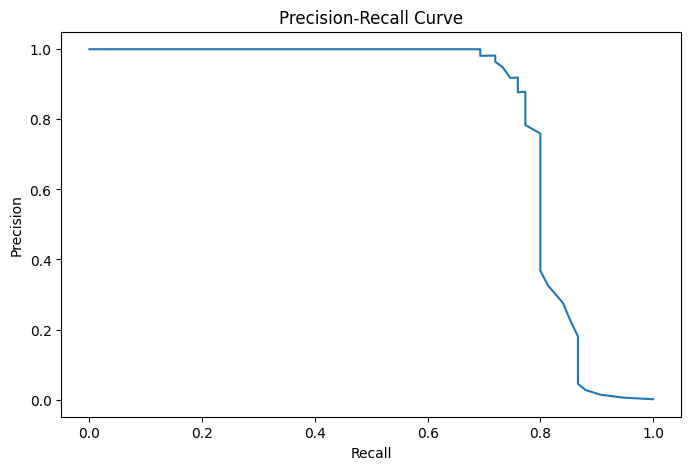

In [13]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_fraud)

plt.figure(figsize=(8,5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [14]:
for p, r, t in zip(precision, recall, thresholds):
    if r >= 0.80:
        best_p, best_r, best_t = p, r, t

print(f'Threshold: {best_t:.2f} | Precision: {best_p:.2f} | Recall: {best_r:.2f}')

Threshold: 0.28 | Precision: 0.76 | Recall: 0.80


In [15]:
y_pred_tuned = (y_proba_fraud >= 0.28).astype(int)
print(classification_report(y_test, y_pred_tuned, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.76      0.80      0.78        75

    accuracy                           1.00     56962
   macro avg       0.88      0.90      0.89     56962
weighted avg       1.00      1.00      1.00     56962



### Threshold Tuning — Results

Optimal threshold: **0.28** (vs default 0.5)

```
RF (SMOTE + threshold 0.28):   Precision 0.76 | Recall 0.80 | F1 0.78
```

By lowering the threshold from 0.5 to 0.28, the model now catches 80% of fraudsters
instead of 72%, at the cost of precision dropping from 0.98 to 0.76.

Trade-off: 24 out of 100 flagged transactions are false alarms — acceptable for a fraud system
where missing a real fraud is far more costly than a temporary card block.

## 9. Feature Importance

Random Forest exposes `feature_importances_` — how much each feature reduces impurity across all trees.
This lets us verify whether the model's learned signal matches what EDA found.

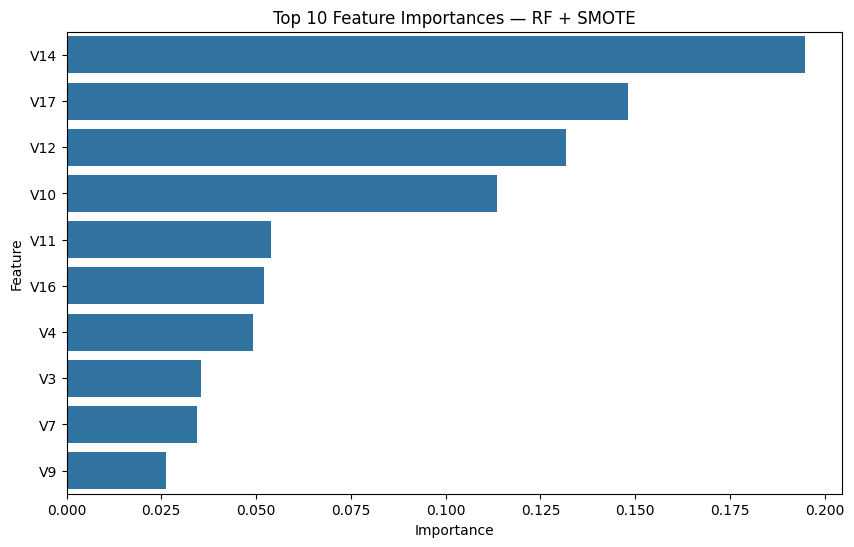

In [16]:
feature_importance = pd.Series(
    RF_smote.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances — RF + SMOTE')
plt.show()

### Feature Importance — Results

Top 10 features: V14 (0.19), V17 (0.15), V12 (0.13), V10 (0.11), V11, V16, V4, V3, V7, V9.

4 out of 5 top features from EDA (V14, V17, V12, V10) match the model's top features —
confirming that the statistical signal found in EDA is real and the model uses it.

Notably, `Amount`, `Time`, and `Hour` did not appear in the top 10.
The V-features are strong enough separators that the model doesn't need them.

**EDA and model agree: V14, V17, V12, V10 are the strongest fraud signals in this dataset.**

## 10. Final Comparison

All models evaluated on the **same time-based test split** (last 20%, 56,962 rows, 75 fraud cases).

| Model | Precision (1) | Recall (1) | F1 (1) | PR-AUC |
|---|---|---|---|---|
| Naive Baseline | 0.00 | 0.00 | 0.00 | - |
| LogReg (default) | 0.86 | 0.57 | 0.69 | - |
| LogReg (balanced) | 0.05 | 0.91 | 0.09 | - |
| RF (balanced) | 0.98 | 0.68 | 0.80 | - |
| RF (SMOTE 0.1) | 0.98 | 0.72 | 0.83 | - |
| RF (SMOTE + threshold 0.28) | 0.76 | 0.80 | 0.78 | **0.807** |

**Final model: RF + SMOTE (sampling_strategy=0.1) + threshold 0.28**

Recall matters more than precision in fraud detection: a missed fraudster means real financial losses,
while a blocked honest client is just an inconvenience. This is a business decision, not a mathematical one.

PR-AUC of 0.807 vs random classifier baseline of ~0.002 confirms the model learns a strong signal from the data.

In [17]:
pr_auc = average_precision_score(y_test, y_proba_fraud)
print(f'PR-AUC: {pr_auc:.3f}')

PR-AUC: 0.807
